In [22]:
# Импортирую библиотеки
# I am importing libraries.
import numpy as np
import pandas as pd
import sklearn
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')

In [23]:
# Загружаю файл CSV
# Uploading CSV file
df = pd.read_csv('/content/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [24]:
# Смотрю размеры датасета
# Checking dataset dimensions
df.shape

(10015, 7)

In [25]:
# Разделяю датафрейм на X И Y где Y-целевая переменная
# Splitting the dataframe into X and Y, where Y is the target
x = df.drop(columns=['dx', 'lesion_id', 'image_id', 'dx_type'])
y = df['dx']

In [26]:
# Определяю, какие колонки числовые, а какие — текстовые
# Determining which columns are numeric and which are text
num_features = ['age']
cat_features = ['sex', 'localization']

# 1. Конвейер для ЧИСЕЛ (затыкаю дыры средним значением + масштабирую)
# 1. Pipeline for NUMERIC data (imputing missing values ​​with the mean + scaling)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # находит пустые age и ставит туда медиану \ finds empty age values ​​and replaces them with the median
    ('scaler', StandardScaler())                  # сжимает возраст в аккуратный диапазон \ compresses age into a neat range
])

# 2. Конвейер для СЛОВ (затыкаю дыры частым словом + перевожу в 0 и 1)
# 2. Pipeline for WORDS (filling gaps with a frequent word + converting to 0s and 1s)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # если где-то пропущен пол/место \ if a gender/location has been missed somewhere
    ('encoder', OneHotEncoder(handle_unknown='ignore'))   # перевожу male/female в цифры \ I'm converting male/female into numbers.
])

# 3. Объединяю их в один большой Диспетчер (ColumnTransformer)
# 3. I combine them into one large dispatcher (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

In [27]:
# Теперь разделяю X И Y на тренировочные и тестовые данные
# Now splitting X and Y into training and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# 1. Создаю словарь с тремя моделями
# Везде включаю защиту от дисбаланса классов (class_weight или аналоги)
# 1. Create a dictionary containing three models
# Include class imbalance handling (class_weight or equivalent) for all of them
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) # у бустинга нет встроенного class_weight, проверим его так
}

# Словарь, куда будут сохраняться готовые обученные пайплайны
# Dictionary where the trained pipelines will be stored
trained_pipelines = {}

# 2. Запускаю цикл обучения
# 2. Starting the training loop
for name, model in models.items():
    print(f" {name} model training has begun...")

    # Создаю пайплайн:  препроцессор (очистка) + текущая модель
    # Creating a pipeline: preprocessor (cleaning) + current model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Обучаю конвейер на тренировочных данных
    # Training the pipeline on the training data
    pipeline.fit(x_train, y_train)

    # Сохраняю обученный конвейер в словарь
    # Saving the trained pipeline to a dictionary
    trained_pipelines[name] = pipeline
    print(f" {name} model has been successfully trained.!\n")

print("All three models are ready for testing.!")


 Logistic Regression model training has begun...
 Logistic Regression model has been successfully trained.!

 Random Forest model training has begun...
 Random Forest model has been successfully trained.!

 Gradient Boosting model training has begun...
 Gradient Boosting model has been successfully trained.!

All three models are ready for testing.!


In [29]:
# Смотрю какие метрики выдает Logictic Regression
# Checking the metrics produced by Logistic Regression
lr_pipeline = trained_pipelines['Logistic Regression']
pred_lr = lr_pipeline.predict(x_test)
print(" --- METRICS FOR LOGISTIC REGRESSION ---")
print(classification_report(y_test, pred_lr))

 --- METRICS FOR LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

       akiec       0.16      0.54      0.25        65
         bcc       0.14      0.34      0.20       103
         bkl       0.39      0.12      0.18       220
          df       0.03      0.78      0.06        23
         mel       0.19      0.09      0.12       223
          nv       0.88      0.23      0.36      1341
        vasc       0.02      0.36      0.04        28

    accuracy                           0.22      2003
   macro avg       0.26      0.35      0.17      2003
weighted avg       0.67      0.22      0.30      2003



In [30]:
# Смотрю какие метрики выдает Random Forest
# Checking the metrics produced by Random Forest
rf_pipeline = trained_pipelines['Random Forest']
pred_rf = rf_pipeline.predict(x_test)
print(" --- METRICS FOR RANDOM FOREST ---")
print(classification_report(y_test, pred_rf))

 --- METRICS FOR RANDOM FOREST ---
              precision    recall  f1-score   support

       akiec       0.19      0.38      0.26        65
         bcc       0.15      0.37      0.22       103
         bkl       0.38      0.27      0.32       220
          df       0.04      0.83      0.08        23
         mel       0.29      0.18      0.22       223
          nv       0.90      0.43      0.58      1341
        vasc       0.04      0.36      0.07        28

    accuracy                           0.38      2003
   macro avg       0.29      0.40      0.25      2003
weighted avg       0.69      0.38      0.47      2003



In [31]:
# Смотрю какие метрики выдает Gradient Boosting
# Checking the metrics produced by Gradient Boosting
gb_pipeline = trained_pipelines['Gradient Boosting']
gb_pred = gb_pipeline.predict(x_test)
print(" ---METRICS FOR GRADIENT BOOSTING ---")
print(classification_report(y_test, gb_pred))

 ---METRICS FOR GRADIENT BOOSTING ---
              precision    recall  f1-score   support

       akiec       0.25      0.02      0.03        65
         bcc       0.50      0.03      0.06       103
         bkl       0.39      0.38      0.39       220
          df       0.00      0.00      0.00        23
         mel       0.38      0.09      0.14       223
          nv       0.75      0.97      0.85      1341
        vasc       0.00      0.00      0.00        28

    accuracy                           0.70      2003
   macro avg       0.32      0.21      0.21      2003
weighted avg       0.62      0.70      0.63      2003



 Почему Градиентный бустинг провалился как медицинский ИИ

 1. Иллюзия высокой точности (Accuracy):У бустинга accuracy = 0.70 только потому, что он почти всем подряд лепит диагноз nv (обычные родинки). У класса nv полнота (recall) равна 0.97 — модель нашла почти все здоровые родинки. Но она сделала это ценой жизней других людей.

 2. Катастрофа с редкими и опасными болезнями:

 1.Меланома (mel): recall упал до 0.09 (обратно на уровень регрессии). Модель пропускает 91% рака кожи!

 2.Классы df и vasc: recall равен 0.00. Модель вообще полностью проигнорировала эти болезни и не нашла ни одного случая из 51.

 3. Почему так произошло?В отличие от Логистической регрессии и Random Forest, у стандартного GradientBoostingClassifier в Scikit-Learn нет встроенного параметра class_weight='balanced'. Бустинг просто погнался за большинством, оптимизируя общую точность, и стал «ленивым» — ему выгоднее угадывать массовые здоровые родинки, чем возиться с редким раком.

  Итог соревнования: Победителем в этой задаче признается Random Forest. Пусть его общая точность ниже (38% против 70%), но его recall для меланомы (18%) и редких болезней в разы выше. В медицине лучше перестраховаться и перепроверить пациента, чем сказать больному человеку, что он здоров.

Why Gradient Boosting Failed as a Medical AI

 1. The Illusion of High Accuracy: Boosting achieves an accuracy of 0.70 simply because it assigns the "nv" diagnosis (common moles) to almost everything. For the "nv" class, recall is 0.97—the model identified nearly all benign moles. However, it did so at the cost of other people's lives.

 2. Catastrophic Failure with Rare and Dangerous Diseases:

 1.Melanoma (mel): Recall dropped to 0.09 (back to baseline levels). The model misses 91% of skin cancer cases!

 2.Classes "df" and "vasc": Recall is 0.00. The model completely ignored these diseases and failed to detect a single case out of 51.

 3. Why did this happen? Unlike Logistic Regression and Random Forest, Scikit-Learn’s standard `GradientBoostingClassifier` lacks a built-in `class_weight='balanced'` parameter. The boosting model simply chased the majority class to optimize overall accuracy and became "lazy"—it was more advantageous for it to correctly identify the common benign moles than to bother with rare cases of cancer.

Competition outcome: Random Forest is the winner for this task. Although its overall accuracy is lower (38% vs. 70%), its recall for melanoma (18%) and rare diseases is significantly higher. In medicine, it is better to err on the side of caution and re-examine a patient than to tell a sick person they are healthy.

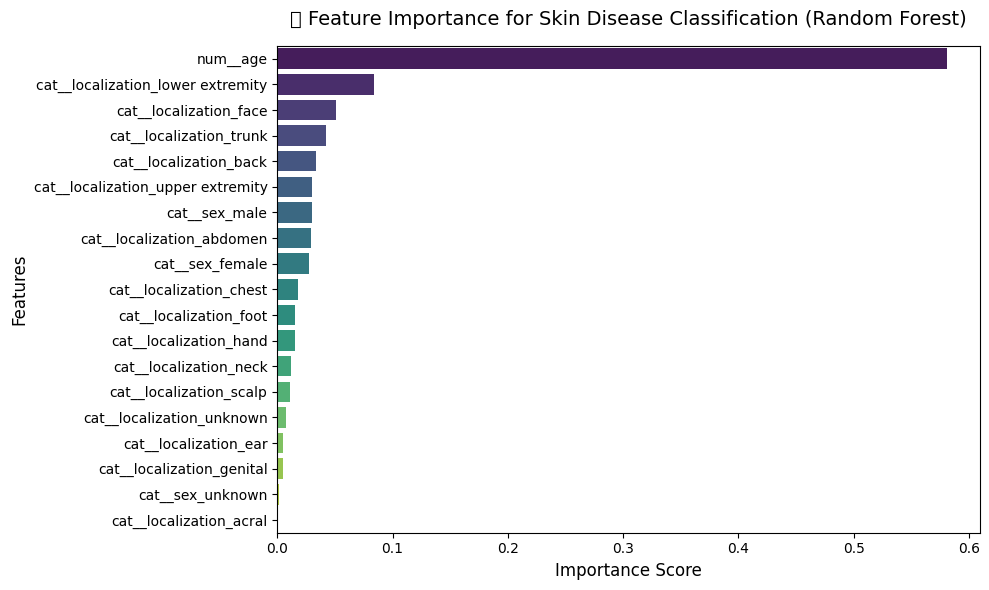

In [32]:
# 1. Извлекаю обученную модель Random Forest из нашего Пайплайна
# 1. Extracting the trained Random Forest model from our pipeline
best_rf_model = trained_pipelines["Random Forest"].named_steps['classifier']

# 2. Получаю названия колонок после препроцессинга (чтобы график был понятным)
# 2. Get column names after preprocessing (to make the plot readable)
feature_names = trained_pipelines["Random Forest"].named_steps['preprocessor'].get_feature_names_out()

# 3. Собираю важность признаков в красивую табличку Pandas
# 3. Compiling feature importance into a neat Pandas table
importances = best_rf_model.feature_importances_
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # Сортирую от самых важных к менее важным \ I am sorting them from most important to least important.

# 4. Строю график с помощью Seaborn и Matplotlib
# 4. Creating a plot using Seaborn and Matplotlib
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance,
    palette='viridis' # красивая градиентная палитра \ beautiful gradient palette
)

# Красиво оформляю график
# Designing a beautiful chart
plt.title('🔍 Feature Importance for Skin Disease Classification (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

# Показываю график на экране
# Showing the graph on the screen
plt.show()